Місто: Харків
Кількість спостережень: 120

Перші 12 місяців:
2015-01-01    -6.1
2015-02-01    -3.6
2015-03-01     0.1
2015-04-01     9.6
2015-05-01    15.8
2015-06-01    19.9
2015-07-01    23.0
2015-08-01    22.5
2015-09-01    16.7
2015-10-01     7.4
2015-11-01     2.1
2015-12-01    -4.3
Freq: MS, Name: температура, dtype: float64


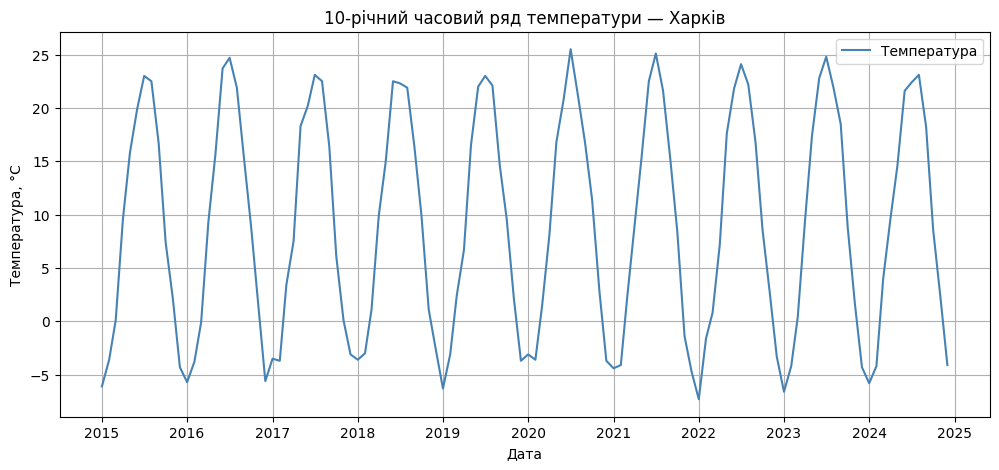


Висновок до Завдання 1:
На графіку видно регулярний річний сезонний цикл температури. Також присутній повільний додатний тренд потепління із заданим темпом 0.03 °C на рік.


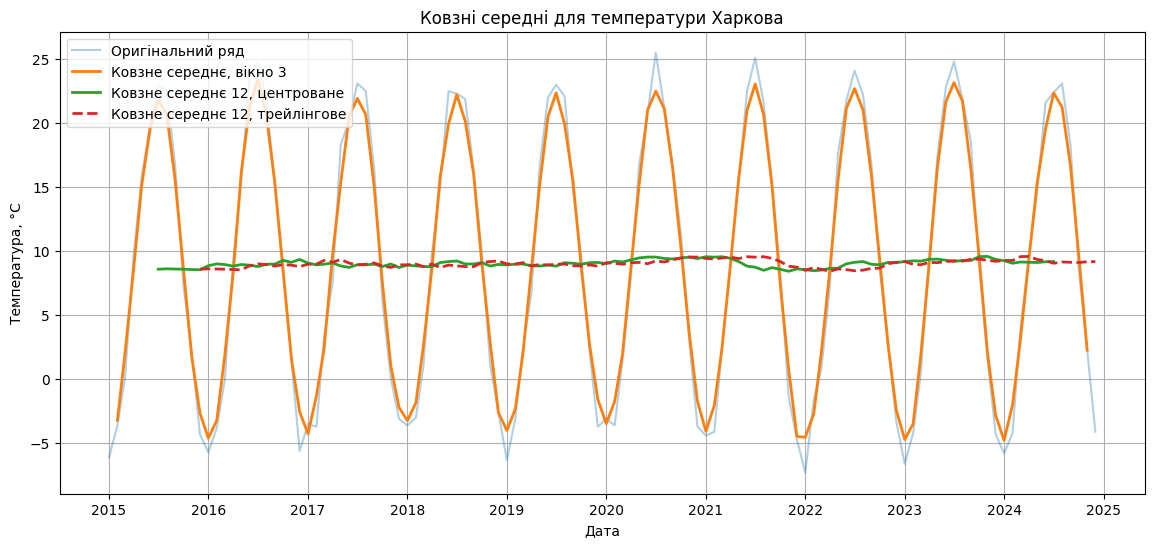


Висновок до Завдання 2:
Вікно 3 згладжує випадковий шум, але сезонність залишається добре помітною. Вікно 12 краще прибирає річну сезонну хвилю, оскільки 12 місяців відповідають одному повному сезонному циклу. Центроване середнє використовує значення навколо поточної дати, тому краще відображає тренд без систематичного запізнення. Трейлінгове середнє використовує лише попередні та поточне значення, тому реагує на зміни із запізненням.


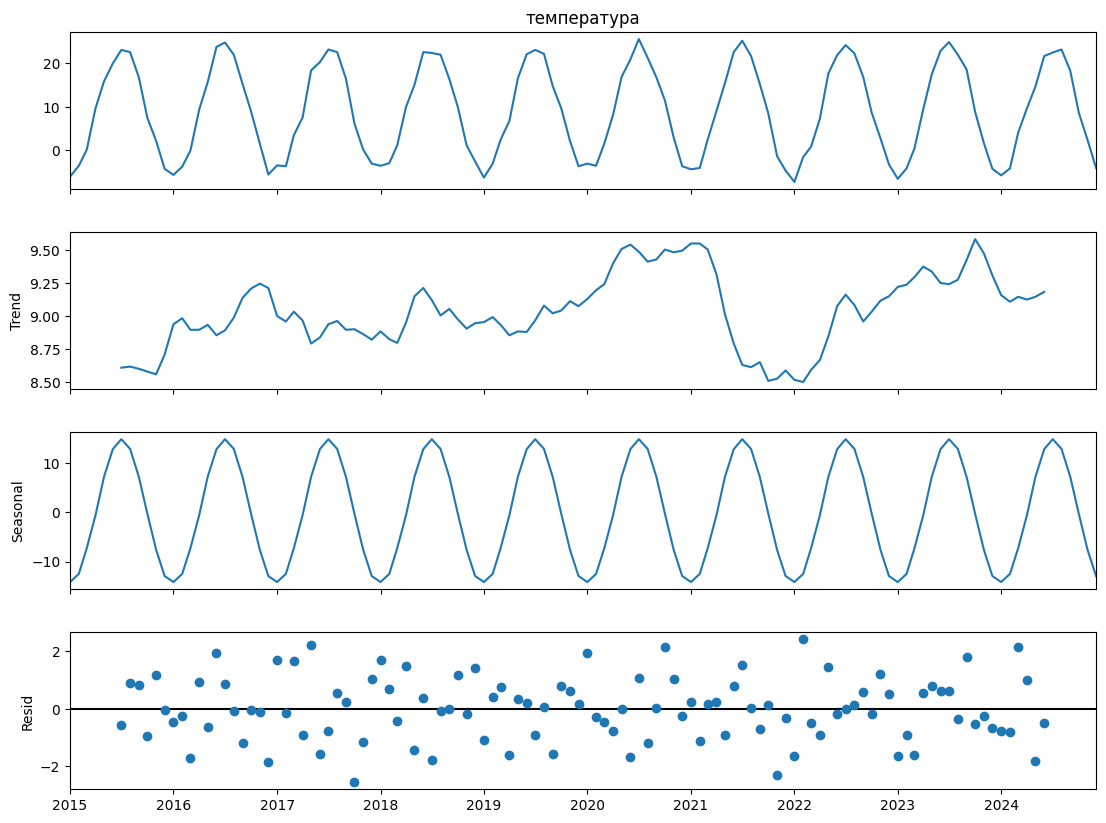


Оцінений тренд:
2015-07-01    8.608333
2015-08-01    8.616667
2015-09-01    8.600000
2015-10-01    8.579167
2015-11-01    8.558333
Freq: MS, Name: trend, dtype: float64

Сезонна складова за місяцями:
Січень    : -14.19 °C
Лютий     : -12.52 °C
Березень  : -7.29 °C
Квітень   : -0.54 °C
Травень   : 7.28 °C
Червень   : 12.92 °C
Липень    : 14.95 °C
Серпень   : 12.97 °C
Вересень  : 7.26 °C
Жовтень   : -0.25 °C
Листопад  : -7.62 °C
Грудень   : -12.96 °C

Найтепліший місяць за seasonal: Липень
Найхолодніший місяць за seasonal: Січень
Стандартне відхилення залишків: 1.10 °C
Закладений шум: 1.20 °C

Висновок до Завдання 3:
Тренд має загалом зростаючий характер, що відповідає заданому тренду потепління 0.03 °C/рік. Сезонна складова демонструє регулярний річний цикл: максимальні значення припадають на літні місяці, а мінімальні — на зимові. Стандартне відхилення залишків близьке до заданого рівня шуму 1.2 °C.

Результати лінійного тренду:
Нахил: 0.0033 °C/місяць
Нахил за рік: 0.0392 °C/рік
p-va

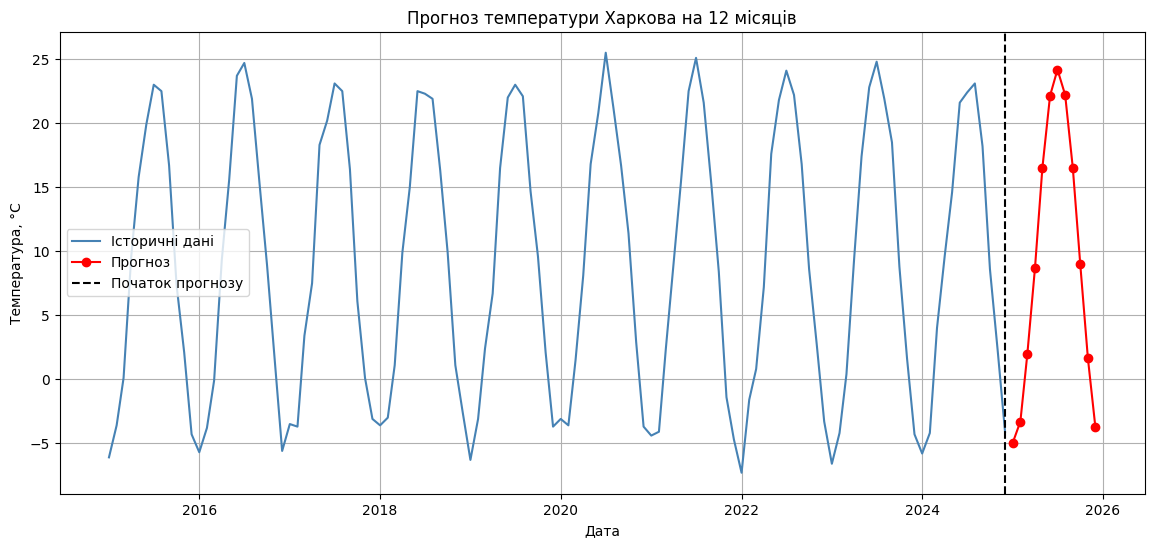


Висновок до Завдання 4:
Прогноз побудований як продовження оціненого лінійного тренду з додаванням типового сезонного ефекту відповідного місяця. Такий прогноз не є гарантією фактичної температури, оскільки реальна погода залежить від багатьох факторів, які не враховані моделлю: атмосферної циркуляції, аномальних погодних явищ, змін клімату та випадкових коливань. Чим далі прогноз виходить за межі наявних даних, тим більша невизначеність.

Статистична перевірка тренду
--------------------------------
H0: істинний нахил тренду = 0
p-value = 0.00007461
alpha = 0.05
Оцінений slope = 0.003264
95% ДІ для slope: [0.001712; 0.004816]
Результат: H0 відхиляємо. Є статистичні підстави вважати, що тренд відрізняється від нуля.

Нахил на всіх 10 роках:
0.003264 °C/місяць

Нахил лише на останніх 3 роках:
0.076474 °C/місяць

Порівняння:
На коротшому часовому відрізку оцінка нахилу може сильніше коливатися через випадковий шум. На всіх 10 роках використовується більше спостережень, тому оцінка довго

In [1]:
# ============================================================
# ПРАКТИКА 22. ЧАСОВИЙ РЯД
# Варіант 4 — Харків
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import linregress

# ============================================================
# ЗАВДАННЯ 1. ПОБУДОВА БАГАТОРІЧНОГО ЧАСОВОГО РЯДУ
# ============================================================

np.random.seed(4)

city = "Харків"
base_temp = 8.8
amplitude = 15
trend_per_year = 0.03
noise_scale = 1.2

n_years = 10

dates = pd.date_range(
    start="2015-01-01",
    periods=n_years * 12,
    freq="MS"
)

month = dates.month

years_elapsed = (
    (dates.year - dates.year[0])
    + (dates.month - 1) / 12
)

seasonal = amplitude * np.cos(
    (month - 7) / 12 * 2 * np.pi
)

trend = trend_per_year * years_elapsed

noise = np.random.normal(
    0,
    noise_scale,
    len(dates)
)

temp = np.round(
    base_temp + trend + seasonal + noise,
    1
)

climate_ts = pd.Series(
    temp,
    index=dates,
    name="температура"
)

print("Місто:", city)
print("Кількість спостережень:", len(climate_ts))
print("\nПерші 12 місяців:")
print(climate_ts.head(12))

# Графік часового ряду
plt.figure(figsize=(12, 5))
plt.plot(
    climate_ts.index,
    climate_ts.values,
    label="Температура",
    color="steelblue"
)
plt.title("10-річний часовий ряд температури — Харків")
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.grid(True)
plt.legend()
plt.show()

print("\nВисновок до Завдання 1:")
print(
    "На графіку видно регулярний річний сезонний цикл температури. "
    "Також присутній повільний додатний тренд потепління "
    "із заданим темпом 0.03 °C на рік."
)


# ============================================================
# ЗАВДАННЯ 2. КОВЗНЕ СЕРЕДНЄ: ВІКНА 3 І 12
# ============================================================

ma3 = climate_ts.rolling(
    window=3,
    center=True
).mean()

ma12_center = climate_ts.rolling(
    window=12,
    center=True
).mean()

ma12_trailing = climate_ts.rolling(
    window=12
).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    climate_ts.index,
    climate_ts,
    alpha=0.35,
    label="Оригінальний ряд"
)

plt.plot(
    ma3.index,
    ma3,
    label="Ковзне середнє, вікно 3",
    linewidth=2
)

plt.plot(
    ma12_center.index,
    ma12_center,
    label="Ковзне середнє 12, центроване",
    linewidth=2
)

plt.plot(
    ma12_trailing.index,
    ma12_trailing,
    label="Ковзне середнє 12, трейлінгове",
    linewidth=2,
    linestyle="--"
)

plt.title("Ковзні середні для температури Харкова")
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.grid(True)
plt.legend()
plt.show()

print("\nВисновок до Завдання 2:")
print(
    "Вікно 3 згладжує випадковий шум, але сезонність залишається добре помітною. "
    "Вікно 12 краще прибирає річну сезонну хвилю, оскільки 12 місяців відповідають "
    "одному повному сезонному циклу. "
    "Центроване середнє використовує значення навколо поточної дати, тому краще "
    "відображає тренд без систематичного запізнення. "
    "Трейлінгове середнє використовує лише попередні та поточне значення, тому "
    "реагує на зміни із запізненням."
)


# ============================================================
# ЗАВДАННЯ 3. ДЕКОМПОЗИЦІЯ seasonal_decompose
# ============================================================

decomposition = seasonal_decompose(
    climate_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 9)
plt.show()

trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
resid_component = decomposition.resid

print("\nОцінений тренд:")
print(trend_component.dropna().head())

print("\nСезонна складова за місяцями:")

seasonal_by_month = (
    seasonal_component
    .groupby(seasonal_component.index.month)
    .mean()
)

month_names = [
    "Січень", "Лютий", "Березень", "Квітень",
    "Травень", "Червень", "Липень", "Серпень",
    "Вересень", "Жовтень", "Листопад", "Грудень"
]

for m, value in seasonal_by_month.items():
    print(f"{month_names[m-1]:10s}: {value:.2f} °C")

warmest_month = seasonal_by_month.idxmax()
coldest_month = seasonal_by_month.idxmin()

resid_std = resid_component.dropna().std()

print("\nНайтепліший місяць за seasonal:",
      month_names[warmest_month - 1])

print("Найхолодніший місяць за seasonal:",
      month_names[coldest_month - 1])

print(f"Стандартне відхилення залишків: {resid_std:.2f} °C")
print(f"Закладений шум: {noise_scale:.2f} °C")

print("\nВисновок до Завдання 3:")
print(
    "Тренд має загалом зростаючий характер, що відповідає заданому "
    "тренду потепління 0.03 °C/рік. "
    "Сезонна складова демонструє регулярний річний цикл: максимальні "
    "значення припадають на літні місяці, а мінімальні — на зимові. "
    "Стандартне відхилення залишків близьке до заданого рівня шуму 1.2 °C."
)


# ============================================================
# ЗАВДАННЯ 4. ПРОГНОЗ НА 12 МІСЯЦІВ УПЕРЕД
# ============================================================

trend_clean = decomposition.trend.dropna()

x = np.arange(len(trend_clean))

fit = linregress(
    x,
    trend_clean.values
)

print("\nРезультати лінійного тренду:")
print(f"Нахил: {fit.slope:.4f} °C/місяць")
print(f"Нахил за рік: {fit.slope * 12:.4f} °C/рік")
print(f"p-value: {fit.pvalue:.6f}")
print(f"stderr: {fit.stderr:.6f}")

n_ahead = 12

x_future = np.arange(
    len(trend_clean),
    len(trend_clean) + n_ahead
)

trend_forecast = (
    fit.intercept +
    fit.slope * x_future
)

seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)

future_dates = pd.date_range(
    climate_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=n_ahead,
    freq="MS"
)

seasonal_forecast = seasonal_by_month.reindex(
    future_dates.month
).values

forecast = pd.Series(
    trend_forecast + seasonal_forecast,
    index=future_dates
)

print("\nПрогноз температури на 12 місяців:")
print(forecast.round(2))

# Графік прогнозу
plt.figure(figsize=(14, 6))

plt.plot(
    climate_ts.index,
    climate_ts.values,
    label="Історичні дані",
    color="steelblue"
)

plt.plot(
    forecast.index,
    forecast.values,
    "o-",
    color="red",
    label="Прогноз"
)

plt.axvline(
    climate_ts.index[-1],
    color="black",
    linestyle="--",
    label="Початок прогнозу"
)

plt.title("Прогноз температури Харкова на 12 місяців")
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.grid(True)
plt.legend()
plt.show()

print("\nВисновок до Завдання 4:")
print(
    "Прогноз побудований як продовження оціненого лінійного тренду "
    "з додаванням типового сезонного ефекту відповідного місяця. "
    "Такий прогноз не є гарантією фактичної температури, оскільки "
    "реальна погода залежить від багатьох факторів, які не враховані "
    "моделлю: атмосферної циркуляції, аномальних погодних явищ, "
    "змін клімату та випадкових коливань. Чим далі прогноз виходить "
    "за межі наявних даних, тим більша невизначеність."
)


# ============================================================
# ЗАВДАННЯ 5. РЕАЛЬНИЙ ТРЕНД ЧИ ШУМ?
# ============================================================

alpha = 0.05

lower = fit.slope - 1.96 * fit.stderr
upper = fit.slope + 1.96 * fit.stderr

print("\nСтатистична перевірка тренду")
print("--------------------------------")
print(f"H0: істинний нахил тренду = 0")
print(f"p-value = {fit.pvalue:.8f}")
print(f"alpha = {alpha}")
print(f"Оцінений slope = {fit.slope:.6f}")
print(f"95% ДІ для slope: [{lower:.6f}; {upper:.6f}]")

if fit.pvalue < alpha:
    print(
        "Результат: H0 відхиляємо. "
        "Є статистичні підстави вважати, що тренд відрізняється від нуля."
    )
else:
    print(
        "Результат: H0 не відхиляємо. "
        "Статистичних підстав стверджувати про ненульовий тренд недостатньо."
    )

# Нахил лише на останніх 3 роках
last_3_years = climate_ts.iloc[-36:]

x_short = np.arange(len(last_3_years))

fit_short = linregress(
    x_short,
    last_3_years.values
)

print("\nНахил на всіх 10 роках:")
print(f"{fit.slope:.6f} °C/місяць")

print("\nНахил лише на останніх 3 роках:")
print(f"{fit_short.slope:.6f} °C/місяць")

print("\nПорівняння:")
print(
    "На коротшому часовому відрізку оцінка нахилу може сильніше "
    "коливатися через випадковий шум. На всіх 10 роках використовується "
    "більше спостережень, тому оцінка довгострокового тренду стабільніша."
)


# ============================================================
# КОНТРОЛЬНЕ ПИТАННЯ 1
# Чому часовий ряд не можна аналізувати як звичайну незалежну вибірку?
# ============================================================

print("""
КОНТРОЛЬНЕ ПИТАННЯ 1:
Часовий ряд не можна повністю розглядати як звичайну незалежну вибірку,
тому що сусідні спостереження пов'язані між собою в часі. У температурному
ряді є сезонність і тренд, тому значення одного місяця може бути пов'язане
зі значеннями сусідніх місяців. Це порушує припущення про незалежність
спостережень, яке часто використовується для звичайних статистичних методів.
""")


# ============================================================
# КОНТРОЛЬНЕ ПИТАННЯ 2
# Чому замале і завелике вікно ковзного середнього — проблема?
# ============================================================

print("""
КОНТРОЛЬНЕ ПИТАННЯ 2:
Занадто мале вікно недостатньо згладжує випадковий шум і частину сезонності.
Занадто велике вікно може надмірно згладити дані та приховати важливі зміни.
Для нашого ряду природним є вікно 12 місяців, тому що сезонний цикл має
період 12 місяців. Таке вікно дозволяє значною мірою усунути річну сезонність
і краще побачити довгостроковий тренд.
""")


# ============================================================
# КОНТРОЛЬНЕ ПИТАННЯ 3
# Різниця між center=False і center=True
# ============================================================

print("""
КОНТРОЛЬНЕ ПИТАННЯ 3:
При center=False трейлінгове ковзне середнє використовує поточне та попередні
значення. Воно придатне для аналізу в реальному часі, тому що не потребує
майбутніх даних.

При center=True середнє розраховується навколо поточної точки і використовує
значення як до, так і після неї. Тому воно краще відображає структуру
історичного ряду, але в реальному часі його неможливо повністю розрахувати,
оскільки майбутні спостереження ще невідомі.
""")


# ============================================================
# КОНТРОЛЬНЕ ПИТАННЯ 4
# Чому p-value важливіше за сам знак slope?
# ============================================================

print("""
КОНТРОЛЬНЕ ПИТАННЯ 4:
Додатний slope лише показує напрямок оціненого тренду. Він сам по собі
не доводить, що потепління є статистично підтвердженим.

p-value перевіряє нульову гіпотезу H0 про нульовий істинний нахил.
Якщо p-value < 0.05, є підстави відхилити H0 і вважати, що нахил
статистично відрізняється від нуля. Тому для висновку про статистично
підтверджений тренд потрібно враховувати p-value та довірчий інтервал,
а не лише знак slope.
""")


# ============================================================
# ДОДАТКОВИЙ ПІДСУМКОВИЙ ВИСНОВОК
# ============================================================

print("\nПІДСУМКОВИЙ ВИСНОВОК:")
print(
    "Для варіанта 4 (Харків) побудовано 10-річний щомісячний часовий ряд "
    "температури з сезонністю, трендом потепління та випадковим шумом. "
    "Ковзне середнє показало вплив розміру вікна на згладжування. "
    "Декомпозиція seasonal_decompose виділила тренд, сезонність і залишок. "
    "На основі тренду та сезонної складової побудовано прогноз на 12 місяців. "
    "Статистичну значущість тренду оцінено за p-value та 95% довірчим інтервалом."
)
